<a href="https://colab.research.google.com/github/takumi-maker/dmd/blob/main/trend_dnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get install -y build-essential
!apt-get install -y python3-dev
!apt-get install -y libatlas-base-dev
!apt-get install -y liblapack-dev
!apt-get install -y libopenblas-dev

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.9ubuntu3).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  javascript-common libjs-sphinxdoc libjs-underscore python3.10-dev
Suggested packages:
  apache2 | lighttpd | httpd
The following NEW packages will be installed:
  javascript-common libjs-sphinxdoc libjs-underscore python3-dev
  python3.10-dev
0 upgraded, 5 newly installed, 0 to remove and 41 not upgraded.
Need to get 796 kB of archives.
After this operation, 1,257 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 javascript-common all 11+nmu1 [5,936 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libjs-underscore all 1.13.2~dfsg-2 [118 kB]
Get:3 http://archive.

In [2]:
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
!tar -xvzf ta-lib-0.4.0-src.tar.gz

--2025-11-27 20:12:19--  http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
Resolving prdownloads.sourceforge.net (prdownloads.sourceforge.net)... 104.18.13.149, 104.18.12.149, 2606:4700::6812:d95, ...
Connecting to prdownloads.sourceforge.net (prdownloads.sourceforge.net)|104.18.13.149|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz [following]
--2025-11-27 20:12:19--  http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz
Resolving downloads.sourceforge.net (downloads.sourceforge.net)... 104.18.13.149, 104.18.12.149, 2606:4700::6812:d95, ...
Reusing existing connection to prdownloads.sourceforge.net:80.
HTTP request sent, awaiting response... 302 Found
Location: http://psychz.dl.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz?viasf=1 [following]
--2025-11-27 20:12:19--  http://psychz.dl.sourcefo

In [3]:
!cd ta-lib && ./configure --prefix=/usr && make && make install

checking for a BSD-compatible install... /usr/bin/install -c
checking whether build environment is sane... yes
checking for a thread-safe mkdir -p... /usr/bin/mkdir -p
checking for gawk... no
checking for mawk... mawk
checking whether make sets $(MAKE)... yes
checking for gcc... gcc
checking for C compiler default output file name... a.out
checking whether the C compiler works... yes
checking whether we are cross compiling... no
checking for suffix of executables... 
checking for suffix of object files... o
checking whether we are using the GNU C compiler... yes
checking whether gcc accepts -g... yes
checking for gcc option to accept ISO C89... none needed
checking for style of include used by make... GNU
checking dependency style of gcc... gcc3
checking build system type... x86_64-unknown-linux-gnu
checking host system type... x86_64-unknown-linux-gnu
checking for a sed that does not truncate output... /usr/bin/sed
checking for grep that handles long lines and -e... /usr/bin/grep
chec

In [4]:
!pip install TA-Lib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 46.3 MB/s eta 0:00:00


In [5]:
import math


import lightgbm as lgb
import matplotlib.pyplot as plt
import numba
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
import seaborn as sns
import talib

from sklearn.ensemble import BaggingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score, KFold, TimeSeriesSplit

In [18]:
df_1 = pd.read_csv("通貨データセット1.csv")
df_1 = df_1.drop(df_1.columns[0], axis=1)
columns_len = len(df_1.columns)
length = len(df_1)
df_1
data_name = 'AUDJPY'
horizon = 1
fee = 0.0000

In [19]:
y_df = df_1
y_df = y_df.drop('USDJPY',axis=1)
y_df = y_df.drop('EURJPY',axis=1)
y_df = y_df.drop('EUDUSD',axis=1)
y_df = y_df.drop('AUDUSD',axis=1)
#y_df = y_df.drop('AUDJPY',axis=1)
y_df = y_df.drop('AUDEUR',axis=1)
#y_df = y_df.drop('GBPUSD',axis=1)
y_df = y_df.drop('EURGBP',axis=1)

In [20]:
df = y_df
df

,AUDJPY,GBPUSD
0,79.515,1.36910
1,79.363,1.35620
2,80.096,1.36290
3,80.387,1.36095
4,80.734,1.35790
...,...,...
769,96.528,1.27020
770,96.822,1.26895
771,97.363,1.27005
772,96.337,1.28050


In [21]:
def calc_features(df,data_name):

    close = df[data_name]


    orig_columns = df.columns


    # 価格(hilo または close)を引いた後、価格(close)で割ることで標準化
    df['BBANDS_upperband'], df['BBANDS_middleband'], df['BBANDS_lowerband'] = talib.BBANDS(close, timeperiod=5, nbdevup=2, nbdevdn=2, matype=0)
    df['LINEARREG'] = (talib.LINEARREG(close, timeperiod=14) - close) / close
    df['LINEARREG_INTERCEPT'] = (talib.LINEARREG_INTERCEPT(close, timeperiod=14) - close) / close


    df['APO'] = talib.APO(close, fastperiod=12, slowperiod=26, matype=0) / close
    df['HT_PHASOR_inphase'], df['HT_PHASOR_quadrature'] = talib.HT_PHASOR(close)
    df['HT_PHASOR_inphase'] /= close
    df['HT_PHASOR_quadrature'] /= close
    df['LINEARREG_SLOPE'] = talib.LINEARREG_SLOPE(close, timeperiod=14) / close
    df['MACD_macd'], df['MACD_macdsignal'], df['MACD_macdhist'] = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
    df['MACD_macd'] /= close
    df['MACD_macdsignal'] /= close
    df['MACD_macdhist'] /= close

    df['MOM'] = talib.MOM(close, timeperiod=10) / close
    df['STDDEV'] = talib.STDDEV(close, timeperiod=5, nbdev=1) / close

    df['RSI'] = talib.RSI(close, timeperiod=14)

    df['STOCHRSI_fastk'], df['STOCHRSI_fastd'] = talib.STOCHRSI(close, timeperiod=14, fastk_period=5, fastd_period=3, fastd_matype=0)
    df['TRIX'] = talib.TRIX(close, timeperiod=30)

    df['HT_DCPERIOD'] = talib.HT_DCPERIOD(close)
    df['HT_DCPHASE'] = talib.HT_DCPHASE(close)
    df['HT_SINE_sine'], df['HT_SINE_leadsine'] = talib.HT_SINE(close)
    df['HT_TRENDMODE'] = talib.HT_TRENDMODE(close)
    df['SMA5'] = talib.SMA(close, 5)
    df['SMA10'] = talib.SMA(close, 10)
    df['SMA20'] = talib.SMA(close, 20)
    df['SMA30'] = talib.SMA(close, 30)


    df['LINEARREG_ANGLE'] = talib.LINEARREG_ANGLE(close, timeperiod=14)
    return df

df = df.dropna()
df = calc_features(df,data_name)
df = df.drop('GBPUSD',axis=1)
df = df.dropna()
df

,AUDJPY,BBANDS_upperband,BBANDS_middleband,BBANDS_lowerband,LINEARREG,LINEARREG_INTERCEPT,APO,HT_PHASOR_inphase,HT_PHASOR_quadrature,LINEARREG_SLOPE,...,HT_DCPERIOD,HT_DCPHASE,HT_SINE_sine,HT_SINE_leadsine,HT_TRENDMODE,SMA5,SMA10,SMA20,SMA30,LINEARREG_ANGLE
88,84.775,84.866966,84.5946,84.322234,-0.000002,-0.011248,0.002992,0.005761,-0.004385,0.000865,...,12.146743,174.851604,0.089736,-0.640801,0,84.5946,84.4874,84.15425,84.052233,4.194600
89,85.544,85.582844,84.7626,83.942356,-0.004710,-0.022873,0.004043,0.002670,-0.005000,0.001397,...,11.979499,185.374824,-0.093671,-0.770233,1,84.7626,84.6622,84.26515,84.126300,6.815338
90,85.288,85.774058,84.9258,84.077542,-0.000335,-0.018383,0.005295,0.000696,-0.003904,0.001388,...,11.867013,205.048258,-0.423381,-0.939980,0,84.9258,84.7595,84.37075,84.176533,6.752757
91,84.977,85.717107,85.0386,84.360093,0.003334,-0.012518,0.006116,-0.001253,-0.000550,0.001219,...,11.906633,205.586892,-0.431879,-0.943147,1,85.0386,84.8165,84.43530,84.206000,5.915863
92,84.529,85.743334,85.0226,84.301866,0.006693,-0.003641,0.006048,0.000062,0.003188,0.000795,...,12.184694,204.543274,-0.415380,-0.936936,1,85.0226,84.7899,84.44340,84.215467,3.844246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
769,96.528,97.761426,96.6732,95.584974,-0.001289,-0.008710,-0.009121,-0.004590,0.014193,0.000571,...,24.043683,18.420386,0.315987,0.894313,0,96.6732,96.0752,96.59570,96.885700,3.153997
770,96.822,97.482180,96.8854,96.288620,-0.001331,-0.014491,-0.007714,0.002546,0.029163,0.001012,...,23.487872,38.880364,0.627696,0.994301,0,96.8854,96.1735,96.51795,96.888667,5.597862
771,97.363,97.553182,96.9046,96.256018,-0.002296,-0.023767,-0.005697,0.015218,0.025507,0.001652,...,22.977653,53.057212,0.799236,0.990129,0,96.9046,96.3281,96.47560,96.915867,9.135332
772,96.337,97.435966,96.7332,96.030434,0.007830,-0.011362,-0.005089,0.021431,-0.002695,0.001476,...,22.820900,66.142555,0.914555,0.932686,0,96.7332,96.4005,96.40315,96.861167,8.094311


In [22]:
features = ['BBANDS_upperband', 'BBANDS_middleband', 'BBANDS_lowerband','LINEARREG', 'LINEARREG_INTERCEPT', 'APO', 'HT_PHASOR_inphase',
       'HT_PHASOR_quadrature', 'LINEARREG_SLOPE', 'MACD_macd',
       'MACD_macdsignal', 'MACD_macdhist', 'MOM', 'STDDEV', 'RSI',
       'STOCHRSI_fastk', 'STOCHRSI_fastd', 'TRIX', 'HT_DCPERIOD', 'HT_DCPHASE',
       'HT_SINE_sine', 'HT_SINE_leadsine', 'HT_TRENDMODE', 'SMA5', 'SMA10',
       'SMA20', 'SMA30', 'LINEARREG_ANGLE']

In [23]:
df.columns

Index(['AUDJPY', 'BBANDS_upperband', 'BBANDS_middleband', 'BBANDS_lowerband',
       'LINEARREG', 'LINEARREG_INTERCEPT', 'APO', 'HT_PHASOR_inphase',
       'HT_PHASOR_quadrature', 'LINEARREG_SLOPE', 'MACD_macd',
       'MACD_macdsignal', 'MACD_macdhist', 'MOM', 'STDDEV', 'RSI',
       'STOCHRSI_fastk', 'STOCHRSI_fastd', 'TRIX', 'HT_DCPERIOD', 'HT_DCPHASE',
       'HT_SINE_sine', 'HT_SINE_leadsine', 'HT_TRENDMODE', 'SMA5', 'SMA10',
       'SMA20', 'SMA30', 'LINEARREG_ANGLE'],
      dtype='object')

In [24]:

df['buy_flag'] = (df[data_name] > (df['SMA30']))
df['sell_flag'] = (df[data_name] < (df['SMA30']))
df['buyfee_flag'] = (df['buy_flag'].shift(1) != df['buy_flag'])
df['sellfee_flag'] = (df['sell_flag'].shift(1) != df['sell_flag'])

df['buyfee'] = np.where(
    df['buyfee_flag'],
    fee,
    0
)

df['sellfee'] = np.where(
    df['sellfee_flag'],
    fee,
    0
)

buyfee = df['buyfee']
sellfee = df['sellfee']

df['y_buy'] = np.where(
    df['buy_flag'],
    df[data_name].shift(-horizon) / df[data_name] - 1 - 2 * fee,
    0
)
df['y_sell'] = np.where(
    df['sell_flag'],
    -(df[data_name].shift(-horizon) / df[data_name]  - 1) - 2 * fee,
    0
)



In [25]:
df

,AUDJPY,BBANDS_upperband,BBANDS_middleband,BBANDS_lowerband,LINEARREG,LINEARREG_INTERCEPT,APO,HT_PHASOR_inphase,HT_PHASOR_quadrature,LINEARREG_SLOPE,...,SMA30,LINEARREG_ANGLE,buy_flag,sell_flag,buyfee_flag,sellfee_flag,buyfee,sellfee,y_buy,y_sell
88,84.775,84.866966,84.5946,84.322234,-0.000002,-0.011248,0.002992,0.005761,-0.004385,0.000865,...,84.052233,4.194600,True,False,True,True,0.0,0.0,0.009071,0.000000
89,85.544,85.582844,84.7626,83.942356,-0.004710,-0.022873,0.004043,0.002670,-0.005000,0.001397,...,84.126300,6.815338,True,False,False,False,0.0,0.0,-0.002993,0.000000
90,85.288,85.774058,84.9258,84.077542,-0.000335,-0.018383,0.005295,0.000696,-0.003904,0.001388,...,84.176533,6.752757,True,False,False,False,0.0,0.0,-0.003646,0.000000
91,84.977,85.717107,85.0386,84.360093,0.003334,-0.012518,0.006116,-0.001253,-0.000550,0.001219,...,84.206000,5.915863,True,False,False,False,0.0,0.0,-0.005272,0.000000
92,84.529,85.743334,85.0226,84.301866,0.006693,-0.003641,0.006048,0.000062,0.003188,0.000795,...,84.215467,3.844246,True,False,False,False,0.0,0.0,0.001183,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
769,96.528,97.761426,96.6732,95.584974,-0.001289,-0.008710,-0.009121,-0.004590,0.014193,0.000571,...,96.885700,3.153997,False,True,False,False,0.0,0.0,0.000000,-0.003046
770,96.822,97.482180,96.8854,96.288620,-0.001331,-0.014491,-0.007714,0.002546,0.029163,0.001012,...,96.888667,5.597862,False,True,False,False,0.0,0.0,0.000000,-0.005588
771,97.363,97.553182,96.9046,96.256018,-0.002296,-0.023767,-0.005697,0.015218,0.025507,0.001652,...,96.915867,9.135332,True,False,True,True,0.0,0.0,-0.010538,0.000000
772,96.337,97.435966,96.7332,96.030434,0.007830,-0.011362,-0.005089,0.021431,-0.002695,0.001476,...,96.861167,8.094311,False,True,True,True,0.0,0.0,0.000000,-0.002118


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31309 (\N{CJK UNIFIED IDEOGRAPH-7A4D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12522 (\N{KATAKANA LETTER RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.pri

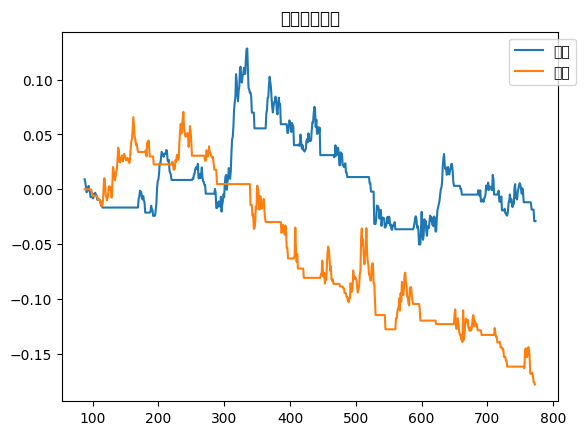

In [26]:
df['y_buy'].cumsum().plot(label='買い')
df['y_sell'].cumsum().plot(label='売り')
plt.title('累積リターン')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000403 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6124
[LightGBM] [Info] Number of data points in the train set: 685, number of used features: 28
[LightGBM] [Info] Start training from score -0.000042
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/tmp/ipython-input-2584284116.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['y_pred_sell'] = my_cross_val_predict(model, df[features].values, df['y_sell'].values, cv=cv_indicies)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
毎時刻、y_predがプラスのときだけトレードした場合の累積リターン


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36023 (\N{CJK UNIFIED IDEOGRAPH-8CB7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22770 (\N{CJK UNIFIED IDEOGRAPH-58F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12426 (\N{HIRAGANA LETTER RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


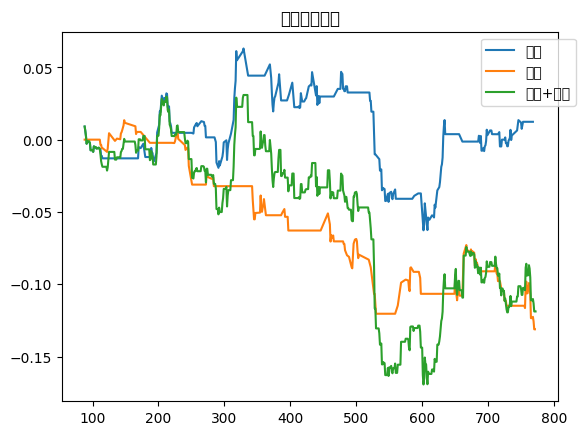

In [27]:
df = df.dropna()

# モデル (コメントアウトで他モデルも試してみてください)
# model = RidgeCV(alphas=np.logspace(-7, 7, num=20))
model = lgb.LGBMRegressor(n_jobs=-1, random_state=1)

# アンサンブル (コメントアウトを外して性能を比較してみてください)
# model = BaggingRegressor(model, random_state=1, n_jobs=1)

# 本番用モデルの学習 (このチュートリアルでは使わない)
# 実稼働する用のモデルはデータ全体で学習させると良い
model.fit(df[features], df['y_buy'])
#joblib.dump(model, 'model_y_buy.xz', compress=True)
model.fit(df[features], df['y_sell'])
#joblib.dump(model, 'model_y_sell.xz', compress=True)

# 通常のCV
cv_indicies = list(KFold().split(df))
# ウォークフォワード法
# cv_indicies = list(TimeSeriesSplit().split(df))

# OOS予測値を計算
def my_cross_val_predict(estimator, X, y=None, cv=None):
    y_pred = y.copy()
    y_pred[:] = np.nan
    for train_idx, val_idx in cv:
        estimator.fit(X[train_idx], y[train_idx])
        y_pred[val_idx] = estimator.predict(X[val_idx])
    return y_pred

df['y_pred_buy'] = my_cross_val_predict(model, df[features].values, df['y_buy'].values, cv=cv_indicies)
df['y_pred_sell'] = my_cross_val_predict(model, df[features].values, df['y_sell'].values, cv=cv_indicies)

# 予測値が無い(nan)行をドロップ
df = df.dropna()

print('毎時刻、y_predがプラスのときだけトレードした場合の累積リターン')
df[df['y_pred_buy'] > 0]['y_buy'].cumsum().plot(label='買い')
df[df['y_pred_sell'] > 0]['y_sell'].cumsum().plot(label='売り')
(df['y_buy'] * (df['y_pred_buy'] > 0) + df['y_sell'] * (df['y_pred_sell'] > 0)).cumsum().plot(label='買い+売り')
plt.title('累積リターン')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

In [ ]:
df

,USDJPY,BBANDS_upperband,BBANDS_middleband,BBANDS_lowerband,LINEARREG,LINEARREG_INTERCEPT,APO,HT_PHASOR_inphase,HT_PHASOR_quadrature,LINEARREG_SLOPE,...,buy_flag,sell_flag,buyfee_flag,sellfee_flag,buyfee,sellfee,y_buy,y_sell,y_pred_buy,y_pred_sell
88,109.155,109.704347,109.383,109.061653,0.003536,-0.011376,-0.002698,0.007142,-0.001118,0.001147,...,False,True,True,True,0.0,0.0,0.000000,-0.002015,-0.000328,-0.002051
89,108.925,109.592843,109.237,108.881157,0.005687,-0.008625,-0.001274,0.008110,-0.001558,0.001101,...,False,True,False,False,0.0,0.0,0.000000,-0.002892,-0.000259,-0.002589
90,108.945,109.517022,109.145,108.772978,0.005232,-0.007605,0.000111,0.006975,-0.008658,0.000987,...,False,True,False,False,0.0,0.0,0.000000,-0.000184,-0.002132,0.000551
91,108.785,109.415699,109.029,108.642301,0.005403,-0.003643,0.001453,0.003207,-0.009199,0.000696,...,False,True,False,False,0.0,0.0,0.000000,-0.002850,-0.002980,-0.008289
92,109.685,109.730899,109.099,108.467101,-0.002219,-0.010141,0.002512,0.001315,-0.007960,0.000609,...,True,False,True,True,0.0,0.0,-0.006382,0.000000,-0.001820,0.000436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764,141.705,148.268552,144.227,140.185448,0.010065,0.048951,-0.015806,-0.017133,-0.000081,-0.002991,...,False,True,False,False,0.0,0.0,0.000000,-0.003740,-0.003301,0.000873
765,142.375,147.128968,143.456,139.783032,0.001783,0.041207,-0.016094,-0.009386,0.015757,-0.003033,...,False,True,False,False,0.0,0.0,0.000000,-0.000070,0.001682,0.012701
766,144.635,146.598654,143.277,139.955346,-0.013461,0.021906,-0.015781,-0.003213,0.003227,-0.002721,...,False,True,False,False,0.0,0.0,0.000000,0.013828,0.000647,0.015235
767,143.565,145.061746,142.822,140.582254,-0.007214,0.027051,-0.015592,-0.003454,-0.019829,-0.002636,...,False,True,False,False,0.0,0.0,0.000000,0.018876,0.001068,0.022737
